# Module 4 — Feature Engineering
### Real-time payment fraud detection for an e-commerce platform

**Input:** `data/processed/transactions_cleaned.parquet` (Module 3 output)
**Outputs:**
- `data/processed/features_train.parquet`, `features_test.parquet` — model-ready matrices
- `models/scaler.joblib`, `models/feature_list.json` — for Module 5/6 reuse
- `Module_08/` — feature dictionary, selection table, imbalance-strategy summary (+ figures)

This module turns cleaned transactions into model-ready features. It has four jobs:
construct **risk-signal features**, **encode** categoricals and **scale** numerics,
**address the severe class imbalance**, and **select** a defensible feature set —
all while respecting three hard constraints carried in from earlier modules:

1. **Velocity is built on `nameDest`, not `nameOrig`.** The EDA showed origin
   accounts are almost all unique, so per-origin velocity/recency is degenerate.
   Customer *destinations* recur, so that is where meaningful velocity lives.
2. **The split is temporal and happens before scaling/resampling.** This is a
   real-time system; the scaler is fit on the past only, resampling touches the
   training fold only, and every recency feature is **causal** (uses prior rows
   only). Anything else leaks the future into the model.
3. **Balance-error terms are engineered here** (deferred from Module 3) with their
   caveat documented: they encode genuine account-draining behaviour, but their
   strength is partly mechanical, so we keep them *and* watch them in monitoring.

> Assumes the cleaned parquet exists (run the Module 3 notebook first).

## Setup

In [23]:
import sys, json
from pathlib import Path

def _find_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "scripts" / "config.py").exists():
            return cand
    return p
ROOT_GUESS = _find_root(Path.cwd())
if str(ROOT_GUESS) not in sys.path:
    sys.path.insert(0, str(ROOT_GUESS))

from scripts.config import ROOT, DATA_PROCESSED, FIGURES, COUNTRIES, FRAUD_TYPES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

REPORTS = ROOT / "Module_08"
MODELS = ROOT / "models"
CLEANED_DATA_PATH = DATA_PROCESSED / "transactions_cleaned.parquet"
for d in (REPORTS, MODELS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    p = FIGURES / f"{name}.png"; fig.savefig(p); print(f"figure -> {p.relative_to(ROOT)}")
def save_table(df, name, index=True):
    p = REPORTS / f"{name}.csv"; df.to_csv(p, index=index); print(f"table  -> {p.relative_to(ROOT)}")

print("Config loaded. FRAUD_TYPES =", FRAUD_TYPES)

Config loaded. FRAUD_TYPES = ['TRANSFER', 'CASH_OUT']


## 1. Load & define the modelling universe

**Reasoning.** PaySim fraud occurs **only** in `TRANSFER` and `CASH_OUT`. The other
three types can be auto-approved by a rule, so the *model's* universe is those two
types. This both reflects the real structure and sharply reduces the imbalance the
classifier must fight.

**What to look for.** After filtering, a much higher (but still small) prevalence
than the ~0.13% headline, and a big drop in row count.

**Business tie-in.** "Never-fraud" transaction types become a free, explainable
auto-approve rule (zero friction, zero review cost); scoring effort concentrates
where fraud is actually possible. We record this as an explicit policy decision.

In [24]:
assert CLEANED_DATA_PATH.exists(), f"Cleaned parquet not found: {CLEANED_DATA_PATH} — run Module 3 first"
full = pd.read_parquet(CLEANED_DATA_PATH)
print(f"cleaned (all types): {len(full):,} rows, prevalence {full.isFraud.mean()*100:.4f}%")

# NOTE: destination-velocity is computed on the FULL cleaned data (all types) so a
# destination's complete footprint is visible, then we filter to the fraud universe.
df = full.sort_values("step").reset_index(drop=True)
model_mask = df.type.isin(FRAUD_TYPES)
print(f"modelling universe ({FRAUD_TYPES}): {int(model_mask.sum()):,} rows, "
      f"prevalence {df.loc[model_mask,'isFraud'].mean()*100:.4f}%")

cleaned (all types): 6,362,620 rows, prevalence 0.1291%
modelling universe (['TRANSFER', 'CASH_OUT']): 2,770,409 rows, prevalence 0.2965%


## 2. Amount & balance-error features

**Reasoning.** `amount` is highly skewed, so we add `log_amount`. We also add the
account-draining signals that define PaySim fraud: the origin/destination
reconciliation errors and a "drained origin" flag (`newbalanceOrig == 0` on a
positive prior balance), plus the ratio of amount to the prior origin balance.

**What to look for.** `log_amount` roughly bell-shaped; drained-origin far more
common in fraud; error terms non-zero on a large share of rows.

**Business tie-in.** "This transfer emptied the account" and "the amount equals the
whole balance" are exactly the human red-flags an analyst uses. **Caveat:** these
error terms are partly *mechanical* in PaySim, so they can look stronger than they
would in production — we keep them but flag them for drift monitoring in Module 7.

In [25]:
eps = 1.0
df["log_amount"] = np.log10(df.amount + eps)
df["orig_balance_err"] = df.oldbalanceOrg - df.amount - df.newbalanceOrig
df["dest_balance_err"] = df.oldbalanceDest + df.amount - df.newbalanceDest
df["drained_origin"] = ((df.newbalanceOrig == 0) & (df.oldbalanceOrg > 0)).astype(int)
df["amount_to_oldbalanceOrg"] = df.amount / (df.oldbalanceOrg + eps)
df["dest_balances_masked"] = ((df.oldbalanceDest == 0) & (df.newbalanceDest == 0)).astype(int)
print("added: log_amount, orig_balance_err, dest_balance_err, drained_origin, "
      "amount_to_oldbalanceOrg, dest_balances_masked")

added: log_amount, orig_balance_err, dest_balance_err, drained_origin, amount_to_oldbalanceOrg, dest_balances_masked


## 3. Geo & behavioural risk signals

**Reasoning.** Several signals already exist from Module 1 (`is_new_device`,
`shipping_billing_mismatch`, `failed_payment_attempts`, `ip_billing_distance_km`,
`account_age_days`, `is_night`). We add the explicit **IP-vs-billing country
mismatch** flag, a log-distance, and a **young-account** flag — turning raw context
into crisp risk indicators.

**What to look for.** Mismatch/new-device/young-account elevated among fraud (as
the EDA lift tables showed), but none separating the classes.

**Business tie-in.** These map directly to review rules in Module 8 — e.g. "foreign
IP + new device + young account" is a classic account-takeover pattern.

In [26]:
df["ip_country_mismatch"] = (df.ip_country != df.home_billing_country).astype(int)
df["log_ip_distance"] = np.log10(df.ip_billing_distance_km + 1.0)
df["young_account"] = (df.account_age_days <= 90).astype(int)
df["high_failed_attempts"] = (df.failed_payment_attempts >= 3).astype(int)
print("added: ip_country_mismatch, log_ip_distance, young_account, high_failed_attempts")

added: ip_country_mismatch, log_ip_distance, young_account, high_failed_attempts


## 4. Velocity & recency — on `nameDest` (causal)

**Reasoning.** The rubric asks for transaction velocity and time-since-last. Because
origin accounts are near-unique, we build these on the **destination**, and strictly
**causally**: for each row we count only *prior* transactions to that destination and
measure the gap since the previous one. We also compute an origin-side counter purely
to *quantify* its degeneracy — then drop it explicitly at feature-assembly time (we
don't rely on a variance threshold to catch it), documenting the EDA-based reason.

**What to look for.** `dest_prior_count` with real spread (mule/collector accounts
accumulate inflows); `orig_prior_count` almost always 0, confirming it carries no
signal before we drop it.

**Business tie-in.** A destination suddenly receiving many transfers in a short
window is a collector/mule signature — a strong, explainable velocity trigger.

In [27]:
# causal prior counts: number of earlier rows sharing the key (data is sorted by step)
df["dest_prior_count"] = df.groupby("nameDest").cumcount()
df["orig_prior_count"] = df.groupby("nameOrig").cumcount()  # expected ~0 (degenerate)

# causal recency: steps since this destination was last seen (NaN -> first sighting)
prev_step = df.groupby("nameDest")["step"].shift(1)
df["dest_steps_since_last"] = (df.step - prev_step)
first_seen = df.dest_steps_since_last.isna()
df["dest_first_seen"] = first_seen.astype(int)
df["dest_steps_since_last"] = df.dest_steps_since_last.fillna(-1)  # sentinel for 'never'

print("dest_prior_count spread:", df.dest_prior_count.describe()[["mean","max"]].round(2).to_dict())
print("orig_prior_count max (expect ~0):", int(df.orig_prior_count.max()))

dest_prior_count spread: {'mean': 5.1, 'max': 112.0}
orig_prior_count max (expect ~0): 2


## 5. Cyclical time & categorical encoding

**Reasoning.** `hour_of_day` is cyclical (hour 23 is adjacent to hour 0), so a raw
integer misleads distance-based/linear models — we encode it as `sin`/`cos`. For
categoricals: within the fraud universe `type` is binary, so a single
`is_transfer` flag suffices; `home_billing_country` and `ip_country` have only ten
values each, so one-hot is clean and interpretable.

**What to look for.** Two smooth cyclical columns; a compact one-hot block; no
explosion in dimensionality (10+10 country columns is fine).

**Business tie-in.** Correct time encoding lets "3am transfers" carry weight without
a spurious ordering; one-hot countries keep the model interpretable for policy.

In [28]:
df["hour_sin"] = np.sin(2*np.pi*df.hour_of_day/24)
df["hour_cos"] = np.cos(2*np.pi*df.hour_of_day/24)
df["is_transfer"] = (df.type == "TRANSFER").astype(int)

country_dummies = pd.concat([
    pd.get_dummies(df.home_billing_country, prefix="home").astype(int),
    pd.get_dummies(df.ip_country, prefix="ip").astype(int),
], axis=1)
df = pd.concat([df, country_dummies], axis=1)
print("added: hour_sin, hour_cos, is_transfer, +", country_dummies.shape[1], "country one-hots")

added: hour_sin, hour_cos, is_transfer, + 20 country one-hots


## 6. Assemble the feature set & temporal split

**Reasoning.** We now select the engineered/context columns as candidate features,
**drop the raw identifiers and leakage-prone flags** (ids, `isFlaggedFraud`, raw
categoricals we already encoded), filter to the fraud universe, and split
**by time**: earliest 80% of `step` for training, latest 20% for test. Time-based
splitting mirrors deployment (predict future from past) and prevents causal velocity
features from leaking.

**What to look for.** Train steps strictly earlier than test steps; fraud present in
both folds; no id/string columns left in `X`.

**Business tie-in.** A model validated on the *future* is the only honest estimate of
how it will behave in production tomorrow.

In [29]:
DROP_COLS = ["nameOrig", "nameDest", "device_id", "home_device_id",
             "browser_fingerprint", "isFlaggedFraud",
             "type", "home_billing_country", "ip_country",
             "hour_of_day",              # replaced by cyclical encoding
             "orig_prior_count"]         # degenerate: origin accounts near-unique (EDA)
LABEL = "isFraud"

model_df = df[df.type.isin(FRAUD_TYPES)].copy()
feature_cols = [c for c in model_df.columns if c not in DROP_COLS + [LABEL]]
# keep only numeric feature columns (safety)
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(model_df[c])]

cut = model_df.step.quantile(0.80)
train_mask = model_df.step <= cut
X_train = model_df.loc[train_mask, feature_cols].reset_index(drop=True)
X_test  = model_df.loc[~train_mask, feature_cols].reset_index(drop=True)
y_train = model_df.loc[train_mask, LABEL].reset_index(drop=True)
y_test  = model_df.loc[~train_mask, LABEL].reset_index(drop=True)

print(f"split at step <= {cut:.0f}")
print(f"train: {X_train.shape}  fraud={int(y_train.sum())} ({y_train.mean()*100:.3f}%)")
print(f"test : {X_test.shape}  fraud={int(y_test.sum())} ({y_test.mean()*100:.3f}%)")
print(f"train step range {model_df.loc[train_mask,'step'].min()}–{model_df.loc[train_mask,'step'].max()} | "
      f"test {model_df.loc[~train_mask,'step'].min()}–{model_df.loc[~train_mask,'step'].max()}")
# temporal splits can leave folds with different prevalence if fraud clusters in time;
# flag it so Module 5 reads test precision/recall in the right context (not a bug).
ratio = (y_test.mean() / max(y_train.mean(), 1e-9))
if ratio > 1.5 or ratio < 0.67:
    print(f"NOTE: test prevalence is {ratio:.1f}x train — fraud clusters in time; "
          f"interpret test metrics against the test base rate, not the train one.")
assert len(feature_cols) == X_train.shape[1]
print(f"\n{len(feature_cols)} candidate features")

split at step <= 354
train: (2217905, 48)  fraud=3955 (0.178%)
test : (552504, 48)  fraud=4258 (0.771%)
train step range 1–354 | test 355–743
NOTE: test prevalence is 4.3x train — fraud clusters in time; interpret test metrics against the test base rate, not the train one.

48 candidate features


## 7. Scale numeric features (fit on train only)

**Reasoning.** We standardise continuous features so scale-sensitive models
(Logistic Regression, distance-based methods, SMOTE) behave. We use a
**RobustScaler** (median/IQR) because amounts and distances have heavy tails, and
we **fit on the training fold only**, then apply to test — never the reverse.
Binary/flag columns are left untouched.

**What to look for.** Continuous columns re-centred; flags unchanged; the fitted
scaler saved for Module 5/6 to reuse identically.

**Business tie-in.** The deployed API (Module 6) must transform a live transaction
with the *exact* statistics learned at training time — hence we persist the scaler,
not just the transformed data.

In [30]:
from sklearn.preprocessing import RobustScaler
import joblib

# scale only genuinely continuous columns; leave binary/flag/count-ish as-is
continuous = ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest",
              "account_age_days","failed_payment_attempts","ip_billing_distance_km",
              "log_amount","orig_balance_err","dest_balance_err","amount_to_oldbalanceOrg",
              "log_ip_distance","dest_prior_count","dest_steps_since_last",
              "hour_sin","hour_cos","step"]
continuous = [c for c in continuous if c in X_train.columns]

scaler = RobustScaler().fit(X_train[continuous])
X_train_s = X_train.copy(); X_test_s = X_test.copy()
X_train_s[continuous] = scaler.transform(X_train[continuous])
X_test_s[continuous]  = scaler.transform(X_test[continuous])

joblib.dump({"scaler": scaler, "continuous": continuous}, MODELS / "scaler.joblib")
print(f"scaled {len(continuous)} continuous features; scaler -> {(MODELS/'scaler.joblib').relative_to(ROOT)}")

scaled 18 continuous features; scaler -> models/scaler.joblib


## 8. Address the severe class imbalance

**Reasoning.** Even within the fraud universe, fraud is a small minority. We lay out
three standard strategies and — critically — apply each **only to the training
fold**, never to test (resampling the test set would fabricate a fantasy score):

- **Class weights** — reweight the loss; no data invented. *Our default*, because it
  keeps the real data distribution and works well with the tree/logistic models in
  Module 5.
- **Random undersampling** — drop majority rows; fast but discards data.
- **SMOTE** — synthesise minority points; can help recall but risks unrealistic
  samples and is costly at this scale.

**What to look for.** Balanced training counts under undersampling/SMOTE; the
computed `class_weight` dict; test set left **untouched**.

**Business tie-in.** The choice trades review workload (precision) against fraud
capture (recall); we hand Module 5 all three so it can pick by the **cost curve**,
not by guesswork.

class_weight (default strategy): {0: np.float64(0.5009), 1: np.float64(280.3925)}


,train_rows,train_fraud,train_fraud_%
strategy,,,
original (weights),2217905,3955,0.178
undersample,7910,3955,50.000
SMOTE,4427900,2213950,50.000


table  -> Module_08/imbalance_strategies.csv
figure -> Module_08/figures/m4_01_imbalance_strategies.png


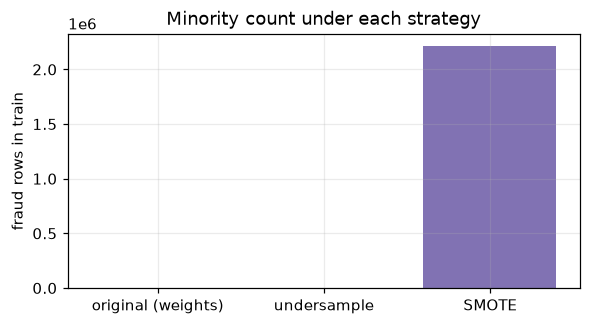

In [31]:
from sklearn.utils.class_weight import compute_class_weight
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

classes = np.array([0, 1])
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = {0: round(weights[0], 4), 1: round(weights[1], 4)}
print("class_weight (default strategy):", class_weight)

rus = RandomUnderSampler(random_state=42)
Xu, yu = rus.fit_resample(X_train_s, y_train)

# SMOTE can be heavy on full data; demonstrate on the training fold
sm = SMOTE(random_state=42, k_neighbors=5)
Xs, ys = sm.fit_resample(X_train_s, y_train)

strat = pd.DataFrame({
    "strategy": ["original (weights)", "undersample", "SMOTE"],
    "train_rows": [len(y_train), len(yu), len(ys)],
    "train_fraud": [int(y_train.sum()), int(yu.sum()), int(ys.sum())],
    "train_fraud_%": [round(y_train.mean()*100,3), round(yu.mean()*100,3), round(ys.mean()*100,3)],
}).set_index("strategy")
display(strat); save_table(strat, "imbalance_strategies")

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(strat.index, strat.train_fraud, color=["#4C72B0","#55A868","#8172B3"])
ax.set_ylabel("fraud rows in train"); ax.set_title("Minority count under each strategy")
save_fig(fig, "m4_01_imbalance_strategies"); plt.show()

## 9. Feature selection

**Reasoning.** We prune on evidence, from the **training fold only**: drop
near-zero-variance columns (a safety net), drop one of any highly correlated pair
(redundancy), then rank what remains by tree-based importance for transparency. We
keep the set compact but do **not** over-prune — imbalanced problems benefit from
complementary weak signals.

**What to look for.** No pair of retained features correlated above ~0.95; a sensible
importance ranking led by amount/balance/velocity signals. (Degenerate origin
velocity was already excluded at assembly, on the EDA rationale, rather than left to
a threshold.)

**Business tie-in.** A lean, non-redundant, ranked feature set is easier to monitor
for drift (Module 7) and to explain in the risk-policy write-up (Module 8).

dropped (near-zero variance): []
dropped (redundant >0.95): ['newbalanceDest', 'orig_balance_err']
final feature count: 46


,importance
oldbalanceOrg,0.1401
failed_payment_attempts,0.1385
amount_to_oldbalanceOrg,0.1177
is_new_device,0.1075
drained_origin,0.0690
dest_balances_masked,0.0567
ip_country_mismatch,0.0546
high_failed_attempts,0.0435
dest_balance_err,0.0344
oldbalanceDest,0.0294


table  -> Module_08/feature_importance.csv
figure -> Module_08/figures/m4_02_feature_importance.png


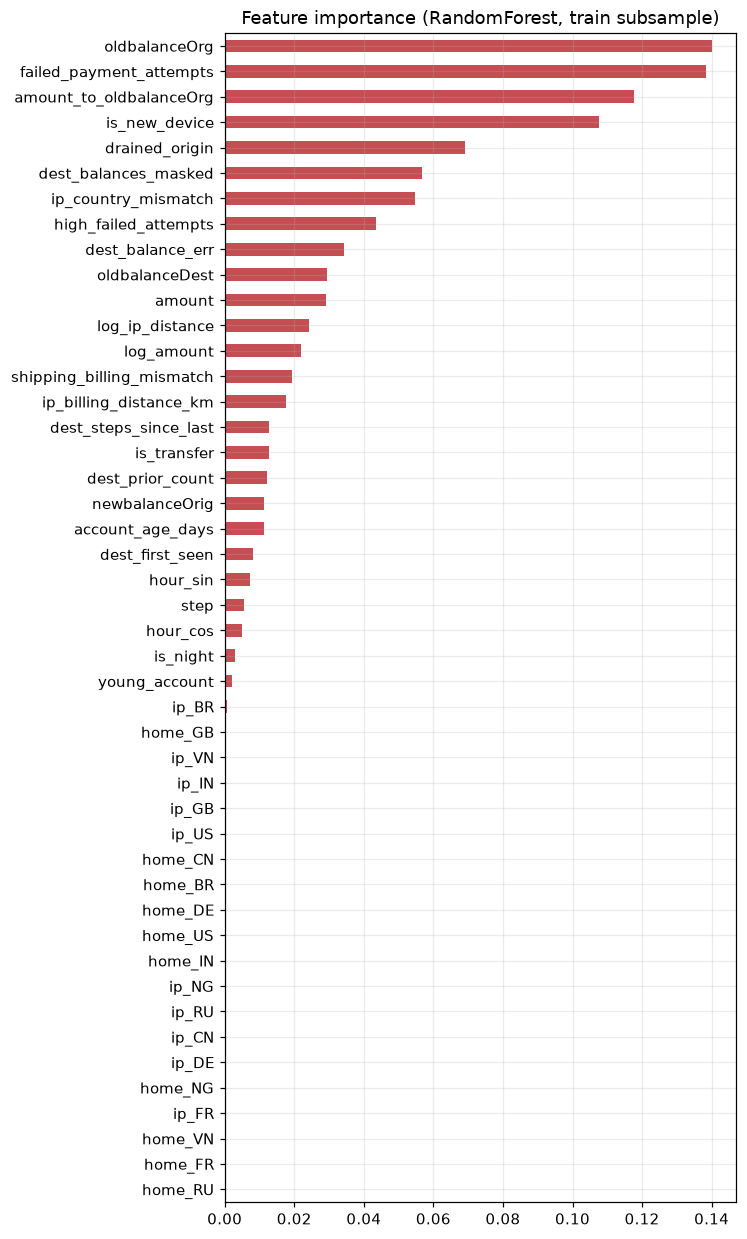

In [32]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier

feat = list(X_train_s.columns)

# (a) near-zero variance
vt = VarianceThreshold(threshold=1e-6).fit(X_train_s[feat])
low_var = [c for c, keep in zip(feat, vt.get_support()) if not keep]
feat = [c for c in feat if c not in low_var]

# (b) redundancy: drop the later column of any |corr| > 0.95 pair
corr = X_train_s[feat].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
redundant = [c for c in upper.columns if (upper[c] > 0.95).any()]
feat = [c for c in feat if c not in redundant]

# (c) importance ranking (subsample for speed; indicative)
n = min(200_000, len(X_train_s))
idx = X_train_s.sample(n=n, random_state=42).index
rf = RandomForestClassifier(n_estimators=120, max_depth=12, n_jobs=-1,
                            class_weight="balanced", random_state=42)
rf.fit(X_train_s.loc[idx, feat], y_train.loc[idx])
imp = pd.Series(rf.feature_importances_, index=feat).sort_values(ascending=False)

print("dropped (near-zero variance):", low_var)
print("dropped (redundant >0.95):", redundant)
print(f"final feature count: {len(feat)}")
display(imp.to_frame("importance").round(4))
save_table(imp.to_frame("importance"), "feature_importance")

fig, ax = plt.subplots(figsize=(6, max(3, 0.3*len(imp))))
imp.iloc[::-1].plot.barh(ax=ax, color="#C44E52")
ax.set_title("Feature importance (RandomForest, train subsample)")
save_fig(fig, "m4_02_feature_importance"); plt.show()

## 10. Save model-ready artifacts & feature dictionary

**Reasoning.** Persist the final train/test matrices (scaled, selected features +
label), the feature list, and a **feature dictionary** documenting every engineered
column, its source, and its leakage note — so Module 5 can load and train
immediately and a reviewer can audit every feature's provenance.

**What to look for.** Train/test parquet written with the selected feature set + the
label; `feature_list.json` and `feature_dictionary.md` in place.

**Business tie-in.** A documented, versioned feature contract is what makes the model
reproducible and the risk policy defensible.

In [33]:
train_out = X_train_s[feat].copy(); train_out[LABEL] = y_train.values
test_out  = X_test_s[feat].copy();  test_out[LABEL]  = y_test.values
# audit columns for the Module-5 cost model & monitoring (NOT features):
# the raw (unscaled) amount is the cost of a missed fraud (C_fn); keep step for temporal analysis.
train_out["amount_raw"] = X_train["amount"].values
test_out["amount_raw"]  = X_test["amount"].values
train_out["step_raw"]   = X_train["step"].values if "step" in X_train else model_df.loc[train_mask,"step"].values
test_out["step_raw"]    = X_test["step"].values if "step" in X_test else model_df.loc[~train_mask,"step"].values
train_out.to_parquet(DATA_PROCESSED / "features_train.parquet", index=False)
test_out.to_parquet(DATA_PROCESSED / "features_test.parquet", index=False)
(MODELS / "feature_list.json").write_text(json.dumps(
    {"features": feat, "label": LABEL, "class_weight": class_weight,
     "continuous_scaled": [c for c in continuous if c in feat],
     "audit_columns": ["amount_raw", "step_raw"]}, indent=2))
print(f"train -> features_train.parquet {train_out.shape}")
print(f"test  -> features_test.parquet  {test_out.shape}")
print(f"feature_list.json + scaler.joblib -> {MODELS.relative_to(ROOT)}")

# feature dictionary (engineered columns only)
FEATURE_DOCS = [
 ("log_amount","numeric","log10(amount+1); tames right-skew","derived from amount"),
 ("orig_balance_err","numeric","oldbalanceOrg-amount-newbalanceOrig; ledger gap (mechanical caveat)","derived"),
 ("dest_balance_err","numeric","oldbalanceDest+amount-newbalanceDest; ledger gap","derived"),
 ("drained_origin","flag","1 if origin emptied (newbalanceOrig==0 & oldbalanceOrg>0)","derived"),
 ("amount_to_oldbalanceOrg","numeric","amount / (oldbalanceOrg+1); share of balance moved","derived"),
 ("dest_balances_masked","flag","1 if both dest balances 0 (PaySim masking)","derived"),
 ("ip_country_mismatch","flag","1 if ip_country != home_billing_country","synthetic geo"),
 ("log_ip_distance","numeric","log10(ip_billing_distance_km+1)","synthetic geo"),
 ("young_account","flag","1 if account_age_days<=90","synthetic account"),
 ("high_failed_attempts","flag","1 if failed_payment_attempts>=3","synthetic behavioural"),
 ("dest_prior_count","numeric","causal count of prior txns to this nameDest","velocity (dest)"),
 ("dest_steps_since_last","numeric","steps since dest last seen (-1=never)","recency (dest)"),
 ("dest_first_seen","flag","1 if first sighting of this destination","recency (dest)"),
 ("hour_sin/hour_cos","numeric","cyclical encoding of hour_of_day","derived time"),
 ("is_transfer","flag","1 if TRANSFER else CASH_OUT (universe is binary)","encoded type"),
 ("home_* / ip_* one-hots","flag","one-hot of home/ip country","encoded geo"),
]
lines = ["# Module 4 — Engineered Feature Dictionary","",
         f"Final feature count: **{len(feat)}**. Modelling universe: {FRAUD_TYPES}. "
         f"Temporal split at step ≤ {cut:.0f} (train) vs later (test).","",
         "| Feature | Type | Definition | Source |","|---|---|---|---|"]
for r in FEATURE_DOCS: lines.append("| `%s` | %s | %s | %s |" % r)
lines += ["","## Leakage & monitoring notes","",
          "- Balance-error / drained-origin features are partly **mechanical** in PaySim; "
          "retained but flagged for drift monitoring (Module 7).",
          "- All velocity/recency features are **causal** (prior rows only) and built on "
          "`nameDest` because origin accounts are near-unique.",
          "- `isFlaggedFraud` and raw identifiers are **excluded** from features.",
          "- Scaler fit on **train only**; resampling applied to **train only**."]
(REPORTS / "feature_dictionary.md").write_text("\n".join(lines), encoding="utf-8")
print(f"feature dictionary -> {(REPORTS/'feature_dictionary.md').relative_to(ROOT)}")

train -> features_train.parquet (2217905, 49)
test  -> features_test.parquet  (552504, 49)
feature_list.json + scaler.joblib -> models
feature dictionary -> Module_08/feature_dictionary.md
